# Multi-Stage RAG Evaluation

Benchmarks every enabled retriever (per `config.yaml` → `retrievers.use`) plus the RRF fusion layer and the Cross-Encoder reranker, against queries generated from the patient medication registry.

**Prereqs:** all entries in `requirements.txt` installed. Heavy first-run cost: ColBERT (~1.6 GB), MedCPT × 2 (~880 MB), SPECTER 2 (~440 MB), Contriever (~440 MB), BioLinkBERT (~440 MB).

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

from src.utils import load_config
from main_pipeline import _selected_retrievers
from evaluate_metrics import (
    generate_eval_queries,
    evaluate,
    build_metrics_table,
    DEFAULT_K_VALUES,
)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
pd.set_option("display.width", 220)

## 1. Config & query sampling

Tune `N_QUERIES` and `CANDIDATE_LIMIT` to balance fidelity vs. runtime. With all 5 retrievers loaded, expect roughly 1–3 s per query on CPU and 0.3–1 s on GPU (after the first query, which pays the model-load cost).

In [2]:
N_QUERIES = 50          # increase for tighter confidence on the means
CANDIDATE_LIMIT = 300   # candidate pool per query (pre-filtered by patient_id)
K_VALUES = (1, 3, 5, 10)

cfg = load_config()
print("Enabled retrievers:", _selected_retrievers(cfg))
print("Pipeline params  :", cfg["params"])

queries = generate_eval_queries(
    cfg["data"]["registry_csv"], n=N_QUERIES, seed=42
)
display(queries.head(5))
print(f"Total queries: {len(queries)}")

Enabled retrievers: ['medcpt', 'specter', 'contriever', 'hybrid']
Pipeline params  : {'batch_size': 16, 'max_length': 512, 'per_retriever_k': 20, 'rrf_k': 60, 'rrf_top_n': 20, 'final_top_n': 5, 'hybrid_dense_weight': 0.5, 'hybrid_bm25_weight': 0.5}


,query,patient_id,note_id,medication,ground_truth_note_ids
0,What is the dosage of ferrous sulfate for pati...,115154574,115154574_2020-06-19_015,ferrous sulfate,{115154574_2020-06-19_015}
1,What is the dosage of zoloft for patient 11230...,112301119,112301119_2023-07-12_216,zoloft,{112301119_2023-07-12_216}
2,What is the dosage of folic acid for patient 1...,112301119,112301119_2019-03-23_140,folic acid,{112301119_2019-03-23_140}
3,What is the dosage of keppra for patient 11515...,115154574,115154574_2016-02-25_003,keppra,{115154574_2016-02-25_003}
4,What is the dosage of reglan for patient 11230...,112301119,112301119_2017-05-18_067,reglan,{112301119_2017-05-18_067}


Total queries: 50


## 2. Run the full multi-stage pipeline on every query

Each query goes through:
1. **Stage 1** — every enabled retriever (latency tracked per backend)
2. **Stage 2** — Reciprocal Rank Fusion of the per-retriever outputs
3. **Stage 3** — Cross-Encoder rerank of the fused top-20

First-query latency includes one-time model loads and is dramatically larger than steady-state — read the **median** and **p90/p99** numbers rather than the first query.

In [3]:
latencies, results_per_system, ground_truths = evaluate(
    queries, cfg, candidate_limit=CANDIDATE_LIMIT
)

queries:   0%|          | 0/50 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

C:\Users\Amulya\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Amulya\.cache\huggingface\hub\models--ncbi--MedCPT-Query-Encoder. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

queries: 100%|██████████| 50/50 [1:01:51<00:00, 74.24s/it]


## 3. Comparison table — every system in one frame

Rows are systems (one per enabled retriever, plus `RRF` after fusion and `FINAL` after Cross-Encoder rerank). Latency columns: per-retriever rows show the retriever's own wall time, `RRF`/`CrossEncoder` rows are just those stages, `FINAL` is the **full** per-query pipeline time.

In [4]:
table = build_metrics_table(results_per_system, ground_truths, latencies, K_VALUES)
display(table)

out_path = "evaluation_results.csv"
table.to_csv(out_path)
print(f"\nSaved: {out_path}")

,Hit@1,P@1,R@1,NDCG@1,Hit@3,P@3,R@3,NDCG@3,Hit@5,P@5,R@5,NDCG@5,Hit@10,P@10,R@10,NDCG@10,MRR,avg_ms,p90_ms,p99_ms
system,,,,,,,,,,,,,,,,,,,,
medcpt,0.020,0.020,0.020,0.020,0.040,0.033,0.100,0.065,0.040,0.028,0.140,0.082,0.040,0.024,0.240,0.113,0.030,28131.466,29522.462,38506.511
specter,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,21829.543,22319.525,29907.233
contriever,0.020,0.020,0.020,0.020,0.020,0.020,0.060,0.043,0.020,0.012,0.060,0.043,0.040,0.016,0.160,0.075,0.023,23322.223,23563.637,29487.141
hybrid,0.020,0.020,0.020,0.020,0.060,0.033,0.100,0.063,0.060,0.044,0.220,0.112,0.060,0.032,0.320,0.144,0.033,290.157,168.604,3604.681
RRF,0.020,0.020,0.020,0.020,0.040,0.013,0.040,0.030,0.060,0.012,0.060,0.038,0.080,0.008,0.080,0.045,0.034,0.046,0.051,0.066
FINAL,0.020,0.020,0.020,0.020,0.020,0.007,0.020,0.020,0.060,0.012,0.060,0.037,0.060,0.006,0.060,0.037,0.030,74131.726,76126.419,101490.315



Saved: evaluation_results.csv


## 4. One detail table per system

Same data, sliced per-system so you can scan a single retriever's IR + latency profile in isolation.

In [5]:
def _detail_view(table: pd.DataFrame, system: str, k_values=K_VALUES) -> pd.DataFrame:
    """Reshape a single row of the wide table into (metric × K) layout."""
    row = table.loc[system]
    ir_metrics = ["Hit", "P", "R", "NDCG"]
    detail = pd.DataFrame(
        {f"@{k}": [row[f"{m}@{k}"] for m in ir_metrics] for k in k_values},
        index=ir_metrics,
    )
    summary = pd.Series(
        {"MRR": row["MRR"], "avg_ms": row["avg_ms"], "p90_ms": row["p90_ms"], "p99_ms": row["p99_ms"]}
    )
    return detail, summary

for system in table.index:
    display(Markdown(f"### {system}"))
    detail, summary = _detail_view(table, system)
    display(detail)
    display(summary.to_frame("value").T)

### medcpt

,@1,@3,@5,@10
Hit,0.020,0.040,0.040,0.040
P,0.020,0.033,0.028,0.024
R,0.020,0.100,0.140,0.240
NDCG,0.020,0.065,0.082,0.113


,MRR,avg_ms,p90_ms,p99_ms
value,0.030,28131.466,29522.462,38506.511


### specter

,@1,@3,@5,@10
Hit,0.000,0.000,0.000,0.000
P,0.000,0.000,0.000,0.000
R,0.000,0.000,0.000,0.000
NDCG,0.000,0.000,0.000,0.000


...

,@1,@3,@5,@10
Hit,0.020,0.040,0.060,0.080
P,0.020,0.013,0.012,0.008
R,0.020,0.040,0.060,0.080
NDCG,0.020,0.030,0.038,0.045


,MRR,avg_ms,p90_ms,p99_ms
value,0.034,0.046,0.051,0.066


### FINAL

,@1,@3,@5,@10
Hit,0.020,0.020,0.060,0.060
P,0.020,0.007,0.012,0.006
R,0.020,0.020,0.060,0.060
NDCG,0.020,0.020,0.037,0.037


,MRR,avg_ms,p90_ms,p99_ms
value,0.030,74131.726,76126.419,101490.315


## 5. Latency distribution

Boxplots of per-query latency per stage. Useful for spotting tail-latency culprits (e.g., ColBERT's PLAID build amortizes but the first call is slow).

C:\Users\Amulya\AppData\Local\Temp\ipykernel_35892\1387341183.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(stage_data, labels=stage_names, showfliers=False)


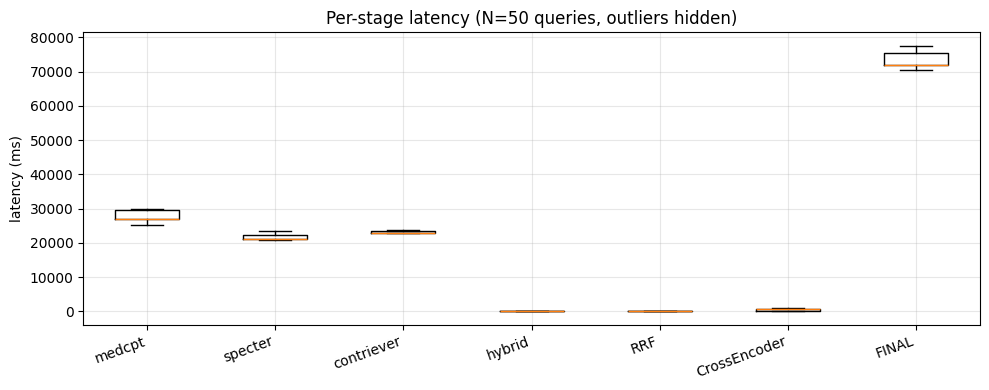

In [6]:
import matplotlib.pyplot as plt

stage_names = list(latencies.keys())
stage_data = [latencies[s] for s in stage_names]

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(stage_data, labels=stage_names, showfliers=False)
ax.set_ylabel("latency (ms)")
ax.set_title(f"Per-stage latency (N={len(queries)} queries, outliers hidden)")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 6. Reading the results

- **Hit@K** — fraction of queries whose ground-truth note appears in the top K.
- **P@K / R@K** — with one ground-truth doc per query, `R@K == Hit@K` and `P@K = Hit@K / K`. The columns are kept separate so a future multi-truth setup drops in without refactoring.
- **MRR** — mean reciprocal rank of the first hit; higher means correct note ranks closer to the top.
- **NDCG@K** — binary-relevance NDCG; identical to MRR-style position weighting for single-truth queries.
- **`FINAL`** row reflects the cross-encoder-reranked top 5 over the RRF fused set. If `FINAL` is worse than `RRF`, the CE model is mis-scoring on your domain (worth trying a domain-tuned CE).
- **`RRF`** row over the **same K** as individual retrievers tells you how much fusion helps without the CE.